In [3]:
# === COURSE REPO SETUP === #

# 1. ENTER your GitHub username (the one that owns your fork)
github_username = "rohanbhuin"

# 2. Name of the repo (don't change unless your fork name is different)
repo_name = "STAT-7220-Applied-Experimental-Design"

# 3. Build the full repo URL for cloning
repo_url = f"https://github.com/{github_username}/{repo_name}.git"

import os

# --- Detect if we're already in a repo ---
cwd = os.getcwd()
if cwd.endswith(repo_name):
    print(f"✅ Already inside repo folder: {cwd}")
else:
    # --- If the repo folder exists, check if it's nested ---
    if os.path.exists(repo_name):
        print(f"⚠️ Found existing folder '{repo_name}'. Skipping clone to avoid nesting.")
    else:
        print(f"📥 Cloning repo from {repo_url}...")
        os.system(f"git clone {repo_url}")

    # --- Change to repo directory ---
    if os.path.exists(repo_name):
        os.chdir(repo_name)
        print(f"📂 Changed directory to: {os.getcwd()}")
    else:
        print("❌ ERROR: Repo folder not found. Please check your GitHub username.")

# --- Check if this is the instructor's repo instead of student's fork ---
# This command needs to be run from within the repository directory
remote_url = os.popen("git config --get remote.origin.url").read().strip()

if "abrown9008" in remote_url:
    print("⚠️ WARNING: You are working in the instructor's repo, not your fork!")
    print("💡 Please fork the repo to your own account and update `github_username` above.")
#else:
    print(f"🔗 Connected to fork at: {remote_url}")

# Set Today's Directory #

today_dir = "Assignments/HW2"
os.chdir(today_dir)
print(f"📂 Changed directory to: {os.getcwd()}")

📥 Cloning repo from https://github.com/rohanbhuin/STAT-7220-Applied-Experimental-Design.git...
📂 Changed directory to: /content/STAT-7220-Applied-Experimental-Design
📂 Changed directory to: /content/STAT-7220-Applied-Experimental-Design/Assignments/HW2


# Homework 2: Randomized Block and Latin Square Designs
## Dr. Austin R. Brown
### School of Data Science & Analytics
### Kennesaw State University

**DUE: February 20, 2026**

**PART 1 INSTRUCTIONS:** You are an educational researcher interested in comparing different methods for teaching data science to undergraduate students. There are three different methods you are interested in comparing: (1) Direct Instruction (traditional method); (2) Inquiry-Based Learning (teacher facilitates student problem solving); (3) Collaborative Learning (students working in small groups). To compare these methods, you decide to randomly recruit undergraduate data science students to be part of a workshop on hypothesis testing basics. Students will be randomly assigned to one of three workshops, where each workshop employs a different teaching method. At the end of the workshop, students will be given a 50-question quiz where their understanding of hypothesis testing will be assessed. Percentage scores on this quiz serve as the outcome of interest.

However, it would be apparent that the prior level of knowledge a student possess about hypothesis testing may serve as a potential confounding variable that you would want to control for. Thus, the Prior Knowledge a given student has about hypothesis testing is categorized into "High" and "Low". The data from this experiment are contained in the `Data Science Teaching Method.xlsx` file. With these data, your tasks are:

**Question 1.** Briefly define the objective of this experiment

**Answer:** The objective of this experiment is to identify if there is a difference in the test score of students involved in the experiment (measured by the "score") associated with the different teaching methods used.

**Question 2.** Specify the outcome variable

**Answer:** The outcome variable is test score (score), which is a quantitative, continuous variable.

**Question 3.** Specify the independent variable and blocking factor. What are some possible lurking variables?

**Answer:** Our primary independent variable is the type of teaching method used. This is a categorical variable with three levels: Direct Instruction,  Inquiry-Based Learning, and Collaborative Learning.

Our blocking factor is the Prior Knowledge a given student has about the subject. This is also a categorical variable with two levels: High and Low.

Some possible lurking variables could include difference in instructors taking the class, duration or frequency of class per week, mode of final test (in-person, online, etc.).

**Question 4.** Briefly explain why a randomized block design would be appropriate here. Similarly, explain why a completely randomized design would not be appropriate.

**Answer:** The students involved in the expretiment (experimental units) have different level of prior knowledge (blocking factor), this means our experimental units are not homogeneous with respect to prior knowledge of the subject. Randomized block design is a type of experimental design that is used when the experimental units are not homogeneous with respect to a particular variable. This is why RBD is most suitable for this study.

For CRD, the experimental units should be homogeneous, which is not the case here. Due to this CRD is not suitable for this study.

**Question 5.** State the null and alternative hypotheses for this experiment.

**Answer:** The null hypothesis, $ H_0 $, is that all the group means of different teaching methods are equal.<br>
The alternative hypothesis, $H_1 $, is that at least two of the group means differ.<br>
Mathematical notation:
$$ \begin{align}
H_0&: \mu_{\text{Direct Instruction}} = \mu_{\text{Inquiry-Based Learning}} = \mu_{\text{Collaborative Learning}} \\
H_1&: \text{At least one pair of means differ}
\end{align}
$$

**Question 6.** Perform appropriate exploratory analysis, including summary statistics **and** data visualizations. Do the results of these analyses support the null or alternative hypothesis more strongly?

**Answer:**

In [4]:
## Import Appropriate Libraries ##
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd

## Import Data ##
teaching = pd.read_excel('Data Science Teaching Method.xlsx')

## Data Integrity Check ##
print(teaching.info())

## Calculate Means and Standard Deviations
## by Prior Knowledge and Teaching Method ##
sum_stats = teaching.groupby(['Prior_Knowledge','Teaching_Method'])['Score'].agg(['mean','std'])

print(sum_stats)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Prior_Knowledge  60 non-null     object 
 1   Teaching_Method  60 non-null     object 
 2   Score            60 non-null     float64
dtypes: float64(1), object(2)
memory usage: 1.5+ KB
None
                                   mean       std
Prior_Knowledge Teaching_Method                  
High            Collaborative    89.390  6.540866
                Direct           81.409  6.400299
                Inquiry          86.618  5.738629
Low             Collaborative    84.810  7.850254
                Direct           73.574  6.028273
                Inquiry          77.611  5.153114


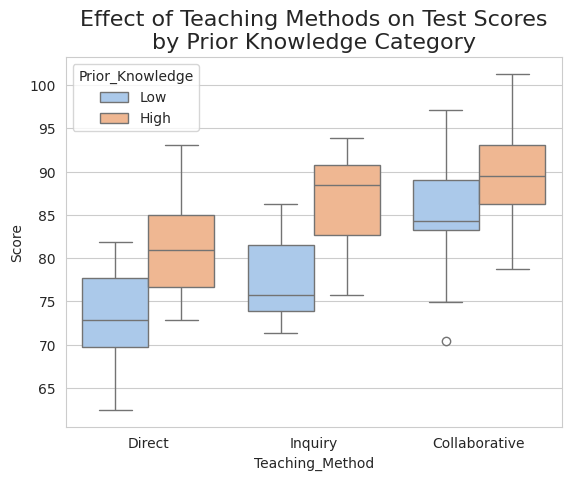

In [5]:
## Create the boxplot using seaborn.
sns.set_style("whitegrid")

sns.boxplot(
    data=teaching,
    x='Teaching_Method',
    y='Score',
    hue='Prior_Knowledge',
    palette='pastel'
)

## Add labels and titles ##
plt.title("Effect of Teaching Methods on Test Scores\nby Prior Knowledge Category",
          loc='center',
          fontsize=16)

## Show the plot ##
plt.show()

As shown in both the table of summary statistics as well as the boxplots, we observe that the Collaborative Learning method yields the highest mean test scores, Direct Teaching method yields the lowest mean test scores and the mean test scores of Inquiry-Based Learning lies in the middle for both the blocking group.

Additionally, it appears that students with low prior knowledge generally had lower test scores across the levels of the teaching methods.

This lends evidence toward the alternative hypothesis.

**Question 7.** Build a two-way ANOVA model. Test the assumption of normality using **both** a visual method and a testing method. Do the results of the normality test(s) support the assumption of normality?

**Answer:**

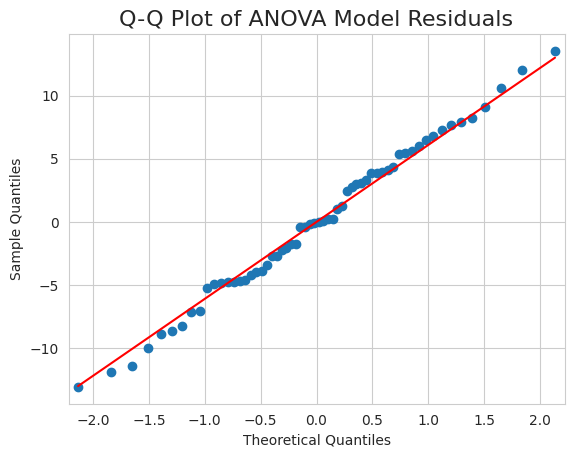

Shapiro-Wilk Test Statistic: 0.9893
Shapiro-Wilk Test P-Value: 0.8794
The residuals are normally distributed (fail to reject H0).


In [10]:
## Assessing Normality ##

## Import scipy ##
import scipy.stats as stats

## Fit model ##
ex_mod = ols("Score~Teaching_Method+Prior_Knowledge",data=teaching).fit()

## Extract Model Residuals ##
ex_residuals = ex_mod.resid

## Generate QQ plot using seaborn ##
sm.qqplot(ex_residuals, line ='s')
plt.title("Q-Q Plot of ANOVA Model Residuals", fontsize=16)
plt.show()

## Perform Shapiro-Wilk Test ##
shapiro_test = stats.shapiro(ex_residuals)
## Get Test Stat ##
shapiro_stat = shapiro_test.statistic
## Get P-Value ##
shapiro_pvalue = shapiro_test.pvalue
print(f"Shapiro-Wilk Test Statistic: {shapiro_stat:.4f}")
print(f"Shapiro-Wilk Test P-Value: {shapiro_pvalue:.4f}")
if shapiro_pvalue < 0.05:
    print("The residuals are not normally distributed (reject H0).")
else:
    print("The residuals are normally distributed (fail to reject H0).")

- Here we get both the test statistic ($W=0.99$) as well as its associated p-value ($p=0.8794$).

- Since $p > \alpha = 0.05$, this tells us the data support the **null** hypothesis, i.e. the assumption of normality is supported by the data.

Based on this result, along with a relatively good looking Q-Q plot, I would conclude that the normality assumption is supported by our data.

**Question 8.** Test the assumption of homogeneity of variance using **both** a visual method and a testing method. Do the results of the test(s) support the assumption of homogeneity of variance?

**Answer:**

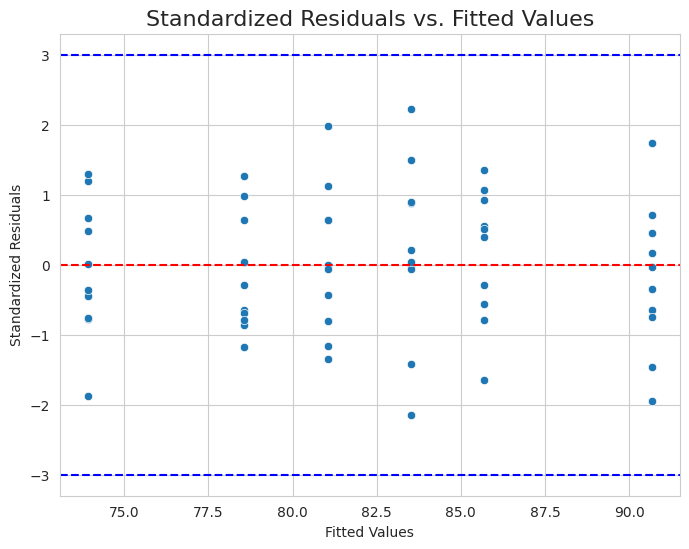

F-statistic: 0.7579465871345045
F p-value: 0.5224437459616452
No heteroscedasticity detected (fail to reject H0). Constant Variance assumed.


In [11]:
## Constant Variance Check ##

## Scatterplot of Standardized Residuals to Fitted Values ##
## Obtain Standardized Residuals ##
standardized_residuals = ex_mod.get_influence().resid_studentized_internal

## Get the fitted values ##
fitted_values = ex_mod.fittedvalues

## Create the plot using seaborn ##
plt.figure(figsize=(8,6))
sns.scatterplot(x=fitted_values, y=standardized_residuals)
plt.axhline(0, color='red', linestyle='--')
plt.axhline(3, color='blue', linestyle='--')
plt.axhline(-3, color='blue', linestyle='--')
plt.title("Standardized Residuals vs. Fitted Values", fontsize=16)
plt.xlabel("Fitted Values")
plt.ylabel("Standardized Residuals")
plt.show()

## B-P Test ##
## Import necessary function: ##
from statsmodels.stats.diagnostic import het_breuschpagan

## Run B-P Test ##
bp_test = het_breuschpagan(ex_mod.resid,ex_mod.model.exog)

## Extract F-statistic ##
f_statistic = bp_test[2]

## Extract its P-Value ##
f_p_value = bp_test[3]

print(f"F-statistic: {f_statistic}")
print(f"F p-value: {f_p_value}")
if f_p_value < 0.05:
    print("Heteroscedasticity detected (reject H0). Constant Variance not assumed.")
else:
    print("No heteroscedasticity detected (fail to reject H0). Constant Variance assumed.")

From the above standardized residuals versus fitted values plot:
- The residuals appear to be randomly scattered around zero across all fitted values.
- All standardized residuals fall within the $\pm$ 3 reference lines.
- The lengths of the vertical spread of the residuals for each group mean seem to be relatively similar across all groups.

The BP test for homogeneity of variance resulted in a p-value of 0.5224, which is greater than the significance level of α = 0.05. Therefore, we fail to reject the null hypothesis of constant variance. This indicates that there is no statistical evidence of heteroscedasticity, and the assumption of homogeneity of variance is supported.

Thus, I would conclude that the constant variance assumption is reasonably supported by the data.

**Question 9.** Report the F-statistic and its associated p-value for the treatment effect. Which of our two hypotheses is more strongly supported? Why?

**Answer:**

In [16]:
## Obtain ANOVA Table ##

## Note, we use Type III SS so that way the Teaching Treatment
## is evaluated after adjusting for Prior Knowledge Category ##
ex_tab = sm.stats.anova_lm(ex_mod,typ=3)

## Add Significance Column ##
ex_tab["Significance"] = np.where(ex_tab["PR(>F)"]<0.05,"Significant","Not Significant")

## Print Only Treatment & Prior Knowledge Rows ##
print(ex_tab.loc[["Teaching_Method","Prior_Knowledge"]])

                     sum_sq   df          F    PR(>F) Significance
Teaching_Method  923.670743  2.0  11.632036  0.000060  Significant
Prior_Knowledge  764.836807  1.0  19.263595  0.000051  Significant


- Our $F_{\text{Stat}} = F(2, 56) = 11.63$ and has an associated p-value < 0.001.

- This indicates that our data more strongly support the **alternative hypothesis**, if we use our traditional $\alpha$-level of 0.05.

- In context, this suggests that the differences in mean test scores levels we observed between the Teaching Method Treatment groups may be statistically meaningful.

**Question 10.** If the data more strongly support the alternative hypothesis, perform Tukey's HSD post-hoc test to determine which levels of the treatment effect are significantly different from each other. If the data more strongly support the null hypothesis, explain why a post-hoc test would not be appropriate.

**Answer:**

Figure(1000x600)
     Multiple Comparison of Means - Tukey HSD, FWER=0.05     
    group1     group2 meandiff p-adj   lower    upper  reject
-------------------------------------------------------------
Collaborative  Direct  -9.6085 0.0003 -15.1184 -4.0986   True
Collaborative Inquiry  -4.9855 0.0838 -10.4954  0.5244  False
       Direct Inquiry    4.623 0.1168  -0.8869 10.1329  False
-------------------------------------------------------------


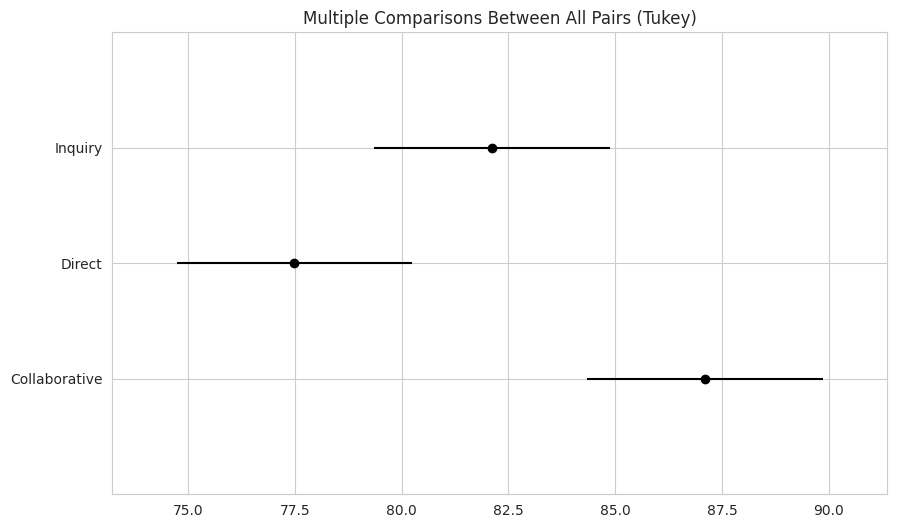

In [15]:
## Import pairwise_tukeyhsd function ##
from statsmodels.stats.multicomp import pairwise_tukeyhsd

## Perform Tukey's HSD test ##
tukey_result = pairwise_tukeyhsd(endog=teaching['Score'], groups=teaching['Teaching_Method'],
                                 alpha=0.05)

## Print Tukey Visualization ##
print(tukey_result.plot_simultaneous())

print(tukey_result)

- These results, as shown by the adjusted $p<0.05$ , indicate that the mean test score of Collaborative learning method is greater than the Direct instruction method mean test score, and is statistically significant.
- However, the difference in mean test scores between Collaborative learning and inquiry based learning as well as Direct instruction and Inquiry-based learning was not found to be statistically different.

**Question 11.** Write a brief, contextual conclusion summarizing the results of your analyses, including potential limitations and future directions of this experiment.

**Answer:**

Conclusion: Overall, we evaluated whether teaching method (Direct Instruction, Inquiry-Based Learning, Collaborative Learning) influences student's hypothesis-testing quiz scores, while accounting for student's prior knowledge (High vs Low).
Descriptive results showed a consistent pattern: students with High prior knowledge scored higher than students with Low prior knowledge across all three methods, and Collaborative Learning produced the highest average scores overall. The two-way ANOVA indicated that Teaching Method had a statistically significant effect on scores F(2,56)=11.63, p<.001.
Tukey’s HSD post-hoc comparisons further clarified that Collaborative Learning led to significantly higher scores than Direct Instruction (adjusted p=0.0003), while Collaborative vs Inquiry and Inquiry vs Direct were not statistically different at α=0.05.
Overall, the findings suggest that collaborative approaches may be more effective than direct instruction for improving understanding of hypothesis testing, and that prior knowledge remains an important predictor of performance regardless of teaching method.

Limitations:
- The analysis used an additive model; a Teaching Method x Prior Knowledge interaction was not tested here, so we cannot conclude whether one method works differently for High vs Low prior-knowledge students.
- Results are based on a single quiz immediately after the workshop, so they may not reflect long-term retention.

Potential Improvements:
- Fit and report a model including the interaction term to check whether teaching methods impact High vs Low prior-knowledge students differently.
- Add a delayed post-test (e.g., after 2-4 weeks) to evaluate retention, not just immediate performance.

**PART 2 INSTRUCTIONS**: Now suppose a university is evaluating the effectiveness of four different online learning platforms (say A, B, C, and D) on student engagement for students taking an undergraduate data science course in an online synchronous format. One section of the course is offered Monday through Thursday in the Morning, Early Afternoon, Mid-Afternoon, and Evening sections. Student engagement is measured through the total number of logins to the online learning platform for a given course section over the course of the
semester. Below is a table describing the study design and factors:


| Section \ Day     | Monday | Tuesday | Wednesday | Thursday |
|-------------------|--------|---------|-----------|----------|
| **Morning**       | A      | B       | C         | D        |
| **Early Afternoon** | B      | C       | D         | A        |
| **Mid-Afternoon** | C      | D       | A         | B        |
| **Evening**       | D      | A       | B         | C        |


Here, our main interest is in comparing engagement across the online learning platforms, but we also want to control for Day of the Week as well as Time of Day, as these could potentially be confounding variables. The data for this experiment are contained in the `Online Learning and Engagement.xlsx` file. With these data, your tasks are:

**Question 1.** Briefly define the objective of this experiment

**Question 2.** Specify the outcome variable

**Question 3.** Specify the independent variable and blocking factors. What are some other possible lurking variables?

**Question 4.** Briefly explain why a Latin Square Design would be appropriate here. Similarly, explain why a completely randomized design or randomized block design would not be appropriate.

**Question 5.** State the null and alternative hypotheses for this experiment.

**Question 6.** Perform appropriate exploratory analysis, including summary statistics **and** data visualizations. Do the results of these analyses support the null or alternative hypothesis more strongly?

**Question 7.** Build a three-way ANOVA model. Test the assumption of normality using **both** a visual method and a testing method. Do the results of the normality test(s) support the assumption of normality?

**Question 8.** Test the assumption of homogeneity of variance using **both** a visual method and a testing method. Do the results of the test(s) support the assumption of homogeneity of variance?

**Question 9.** Report the F-statistic and its associated p-value for the treatment effect. Which of our two hypotheses is more strongly supported? Why?

**Question 10.** If the data more strongly support the alternative hypothesis, perform Tukey's HSD post-hoc test to determine which levels of the treatment effect are significantly different from each other. If the data more strongly support the null hypothesis, explain why a post-hoc test would not be appropriate.

**Question 11.** Write a brief conclusion summarizing the results of your analyses, including potential limitations and future directions of this experiment.